# World Bank WDI Benchmark — CrossCat Paper Reproduction

Reproduces the macroeconomic development analysis from:
> Mansinghka et al. (2016) "CrossCat: A Fully Bayesian Nonparametric Method for Analyzing Heterogeneous, High Dimensional Data", JMLR 17(1):1-49.

**Paper setup (Section 3.3):**
- World Bank Development Indicators: ~200 countries × 300 indicators
- Mixed column types: continuous (GDP, rates), categorical (region, income group)
- 40-80% structural missingness (countries report different subsets)
- Key outputs: dependence structure (Z-matrix), imputation, anomaly detection, country similarity

**This notebook** uses `wbgapi` to fetch live WDI data and runs JAX-CrossCat inference on Kaggle GPU/TPU.

**Instructions:**
1. Upload to **Kaggle** (select P100 accelerator) or **Colab** (select T4/A100 runtime)
2. Run all cells
3. States are checkpointed — if the session dies, re-run and it resumes from the last checkpoint

## 1. Setup — Install jaxcross from GitHub

In [1]:
!nvidia-smi

Tue Mar 31 07:57:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

WORKDIR = "/kaggle/working/jaxcross"
BRANCH = "chore/update-benchmark-notebooks-for-arxiv"  # @param {type:"string"}

!git clone https://github.com/sambhal-labs/jaxcross.git {WORKDIR} 2>/dev/null \
    || (cd {WORKDIR} && git pull)
os.chdir(WORKDIR)

!git fetch origin && git checkout {BRANCH} && git pull origin {BRANCH}

# Preserve Kaggle's pre-installed JAX+CUDA stack to avoid ptxas version mismatch.
%pip install -e . --no-deps -q
%pip install wbgapi seaborn matplotlib scikit-learn -q

print(f"Branch: {BRANCH}")
print(f"Working directory: {os.getcwd()}")
print("Setup complete.")

remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 506 bytes | 253.00 KiB/s, done.
From https://github.com/sambhal-labs/jaxcross
   9ce7277..42e7d4e  chore/update-benchmark-notebooks-for-arxiv -> origin/chore/update-benchmark-notebooks-for-arxiv
Updating 9ce7277..42e7d4e
Fast-forward
 crosscat/packed_inference.py | 6 +++---
 1 file changed, 3 insertions(+), 3 deletions(-)
Already on 'chore/update-benchmark-notebooks-for-arxiv'
Your branch is up to date with 'origin/chore/update-benchmark-notebooks-for-arxiv'.
From https://github.com/sambhal-labs/jaxcross
 * branch            chore/update-benchmark-notebooks-for-arxiv -> FETCH_HEAD
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing ed

## 2. Verify GPU and imports

In [3]:
import json
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wbgapi as wb

import crosscat
from crosscat import (
    collect_diagnostics,
    initialize,
    load_latest_checkpoint,
    load_state,
    save_checkpoint,
    save_state,
)
from crosscat.packed import pack_state, packed_gibbs_sweep, unpack_state
from crosscat.packed_inference import (
    batch_impute_column,
    batch_row_similarity,
    batch_row_typicality,
    packed_anomaly_score,
    packed_dependence_matrix,
    packed_mutual_information,
)
from crosscat.types import ColumnType

print(f"jaxcross version: {crosscat.__version__}")
print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")
print(f"Backend: {jax.default_backend()}")

jaxcross version: 0.10.1
JAX version: 0.7.2
Devices: [CudaDevice(id=0)]
Backend: gpu


## 3. Configuration

Adjust these parameters based on your GPU.

| Parameter | P100 (Kaggle) | T4 | A100 | Paper |
|-----------|--------------|-----|------|-------|
| `N_INDICATORS` | 100 | 100 | 300 | ~300 |
| `N_CHAINS` | 3 | 2 | 5 | 10 |
| `N_SWEEPS` | 100 | 50 | 200 | 1000 |

With 200 rows (countries), even 300 columns is fast — fewer rows than the MNIST benchmark.

In [4]:
# ---- Benchmark Configuration ----
# Matching original CrossCat paper: 10 chains x 1000 iterations
# (Mansinghka et al. 2016, Section 3.1, Fig 12 caption)
N_INDICATORS = 100  # Paper used 74 (Dartmouth Atlas); we use ~100 WDI indicators
N_CHAINS = 10  # Paper: "10 samples"
N_SWEEPS = 1000  # Paper: "1000 iterations"
DATA_YEAR = 2019  # Most recent pre-COVID year with good coverage
SEED = 42

# Minimum data coverage: drop indicators with fewer than this fraction of countries reporting
MIN_COVERAGE = 0.30  # At least 30% of countries must report

print(f"Config: {N_INDICATORS} indicators, year={DATA_YEAR}")
print(f"  {N_CHAINS} chains x {N_SWEEPS} sweeps (matching paper)")

Config: 100 indicators, year=2019
  10 chains x 1000 sweeps (matching paper)


## 4. Data Loading — Curated WDI Indicators

We select indicators across major development dimensions to maximize column type diversity
and ensure meaningful cross-column dependencies.

**Dimensions:**
- Economy (GDP, GNI, inflation, trade)
- Health (life expectancy, mortality, immunization)
- Education (enrollment, literacy, expenditure)
- Infrastructure (electricity, internet, sanitation)
- Environment (CO2, forest area, renewable energy)
- Demographics (population, urbanization, fertility)
- Governance (ease of business, tax revenue)

In [5]:
# Curated indicator codes organized by development dimension.
# Each tuple: (indicator_code, short_name, expected_type)
# We fetch broadly and then select the top N_INDICATORS by data coverage.

INDICATOR_CATALOG = [
    # === Economy ===
    ("NY.GDP.PCAP.PP.KD", "GDP per capita PPP", "continuous"),
    ("NY.GDP.MKTP.KD.ZG", "GDP growth %", "continuous"),
    ("NY.GNP.PCAP.CD", "GNI per capita", "continuous"),
    ("FP.CPI.TOTL.ZG", "Inflation CPI %", "continuous"),
    ("NE.TRD.GNFS.ZS", "Trade % GDP", "continuous"),
    ("NE.EXP.GNFS.ZS", "Exports % GDP", "continuous"),
    ("NE.IMP.GNFS.ZS", "Imports % GDP", "continuous"),
    ("BN.CAB.XOKA.GD.ZS", "Current account % GDP", "continuous"),
    ("GC.DOD.TOTL.GD.ZS", "Govt debt % GDP", "continuous"),
    ("GC.REV.XGRT.GD.ZS", "Revenue % GDP", "continuous"),
    ("GC.TAX.TOTL.GD.ZS", "Tax revenue % GDP", "continuous"),
    ("GC.XPN.TOTL.GD.ZS", "Govt expenditure % GDP", "continuous"),
    ("NV.AGR.TOTL.ZS", "Agriculture % GDP", "continuous"),
    ("NV.IND.TOTL.ZS", "Industry % GDP", "continuous"),
    ("NV.SRV.TOTL.ZS", "Services % GDP", "continuous"),
    ("FM.LBL.BMNY.GD.ZS", "Broad money % GDP", "continuous"),
    ("FR.INR.RINR", "Real interest rate %", "continuous"),
    ("PA.NUS.PPPC.RF", "PPP conversion factor", "continuous"),
    ("BX.KLT.DINV.WD.GD.ZS", "FDI inflow % GDP", "continuous"),
    ("DT.DOD.DECT.GN.ZS", "External debt % GNI", "continuous"),
    ("SL.UEM.TOTL.ZS", "Unemployment %", "continuous"),
    ("SL.TLF.CACT.ZS", "Labor force participation %", "continuous"),
    ("SL.AGR.EMPL.ZS", "Employment in agriculture %", "continuous"),
    ("SL.IND.EMPL.ZS", "Employment in industry %", "continuous"),
    ("SL.SRV.EMPL.ZS", "Employment in services %", "continuous"),
    ("NE.GDI.TOTL.ZS", "Gross capital formation % GDP", "continuous"),
    ("NY.GNS.ICTR.ZS", "Gross savings % GDP", "continuous"),
    ("IC.BUS.EASE.XQ", "Ease of doing business score", "continuous"),
    # === Health ===
    ("SP.DYN.LE00.IN", "Life expectancy", "continuous"),
    ("SP.DYN.LE00.MA.IN", "Life expectancy male", "continuous"),
    ("SP.DYN.LE00.FE.IN", "Life expectancy female", "continuous"),
    ("SH.DYN.MORT", "Under-5 mortality per 1000", "continuous"),
    ("SH.DYN.NMRT", "Neonatal mortality per 1000", "continuous"),
    ("SP.DYN.IMRT.IN", "Infant mortality per 1000", "continuous"),
    ("SH.STA.MMRT", "Maternal mortality per 100K", "continuous"),
    ("SH.IMM.MEAS", "Measles immunization %", "continuous"),
    ("SH.IMM.IDPT", "DPT immunization %", "continuous"),
    ("SH.XPD.CHEX.GD.ZS", "Health expenditure % GDP", "continuous"),
    ("SH.MED.PHYS.ZS", "Physicians per 1000", "continuous"),
    ("SH.MED.BEDS.ZS", "Hospital beds per 1000", "continuous"),
    ("SH.TBS.INCD", "TB incidence per 100K", "continuous"),
    ("SH.HIV.INCD.TL.P3", "HIV incidence per 1000", "continuous"),
    ("SH.PRV.SMOK.MA", "Smoking prevalence male %", "continuous"),
    ("SH.PRV.SMOK.FE", "Smoking prevalence female %", "continuous"),
    ("SH.STA.STNT.ZS", "Stunting prevalence %", "continuous"),
    ("SH.STA.OWGH.ZS", "Overweight prevalence %", "continuous"),
    # === Education ===
    ("SE.PRM.ENRR", "Primary enrollment gross %", "continuous"),
    ("SE.SEC.ENRR", "Secondary enrollment gross %", "continuous"),
    ("SE.TER.ENRR", "Tertiary enrollment gross %", "continuous"),
    ("SE.ADT.LITR.ZS", "Adult literacy rate %", "continuous"),
    ("SE.XPD.TOTL.GD.ZS", "Education expenditure % GDP", "continuous"),
    ("SE.PRM.CMPT.ZS", "Primary completion rate %", "continuous"),
    ("SE.ENR.PRSC.FM.ZS", "School enrollment gender parity", "continuous"),
    ("SE.COM.DURS", "Compulsory education years", "continuous"),
    # === Infrastructure ===
    ("EG.ELC.ACCS.ZS", "Electricity access %", "continuous"),
    ("IT.NET.USER.ZS", "Internet users %", "continuous"),
    ("IT.CEL.SETS.P2", "Mobile subscriptions per 100", "continuous"),
    ("SH.H2O.BASW.ZS", "Basic water access %", "continuous"),
    ("SH.STA.BASS.ZS", "Basic sanitation %", "continuous"),
    ("IS.AIR.DPRT", "Air departures", "continuous"),
    ("IS.RRS.TOTL.KM", "Rail lines km", "continuous"),
    # === Environment ===
    ("EN.ATM.CO2E.PC", "CO2 emissions per capita", "continuous"),
    ("EN.ATM.CO2E.KT", "CO2 emissions total kt", "continuous"),
    ("AG.LND.FRST.ZS", "Forest area %", "continuous"),
    ("EG.USE.PCAP.KG.OE", "Energy use per capita", "continuous"),
    ("EG.FEC.RNEW.ZS", "Renewable energy %", "continuous"),
    ("AG.LND.ARBL.ZS", "Arable land %", "continuous"),
    ("AG.LND.TOTL.K2", "Land area sq km", "continuous"),
    ("ER.H2O.FWTL.ZS", "Freshwater withdrawal %", "continuous"),
    ("EN.ATM.PM25.MC.M3", "PM2.5 air pollution", "continuous"),
    # === Demographics ===
    ("SP.POP.TOTL", "Population total", "continuous"),
    ("SP.POP.GROW", "Population growth %", "continuous"),
    ("SP.URB.TOTL.IN.ZS", "Urban population %", "continuous"),
    ("SP.DYN.TFRT.IN", "Fertility rate", "continuous"),
    ("SP.DYN.CBRT.IN", "Birth rate per 1000", "continuous"),
    ("SP.DYN.CDRT.IN", "Death rate per 1000", "continuous"),
    ("SP.POP.DPND", "Age dependency ratio %", "continuous"),
    ("SP.POP.65UP.TO.ZS", "Population 65+ %", "continuous"),
    ("SP.POP.0014.TO.ZS", "Population 0-14 %", "continuous"),
    ("SM.POP.NETM", "Net migration", "continuous"),
    ("SP.POP.DNST", "Population density", "continuous"),
    ("SP.RUR.TOTL.ZS", "Rural population %", "continuous"),
    ("SP.DYN.AMRT.MA", "Adult mortality rate male", "continuous"),
    ("SP.DYN.AMRT.FE", "Adult mortality rate female", "continuous"),
    # === Gender & Inequality ===
    ("SG.GEN.PARL.ZS", "Women in parliament %", "continuous"),
    ("SL.TLF.CACT.FE.ZS", "Female labor force participation %", "continuous"),
    ("SI.POV.GINI", "Gini index", "continuous"),
    ("SI.POV.DDAY", "Poverty headcount $2.15/day %", "continuous"),
    ("SI.DST.10TH.10", "Income share top 10%", "continuous"),
    ("SI.DST.FRST.10", "Income share bottom 10%", "continuous"),
    # === Financial ===
    ("FD.AST.PRVT.GD.ZS", "Domestic credit to private sector % GDP", "continuous"),
    ("BX.TRF.PWKR.DT.GD.ZS", "Remittances received % GDP", "continuous"),
    ("DT.ODA.ODAT.GN.ZS", "ODA received % GNI", "continuous"),
    ("CM.MKT.LCAP.GD.ZS", "Market capitalization % GDP", "continuous"),
    # === Military & Governance ===
    ("MS.MIL.XPND.GD.ZS", "Military expenditure % GDP", "continuous"),
    ("IQ.CPA.GNDR.XQ", "Gender equality rating (CPIA)", "continuous"),
    ("CC.EST", "Control of corruption estimate", "continuous"),
    ("GE.EST", "Government effectiveness estimate", "continuous"),
    ("RQ.EST", "Regulatory quality estimate", "continuous"),
    ("RL.EST", "Rule of law estimate", "continuous"),
    ("VA.EST", "Voice and accountability estimate", "continuous"),
    ("PV.EST", "Political stability estimate", "continuous"),
]

print(f"Catalog: {len(INDICATOR_CATALOG)} indicators across 8 dimensions")

Catalog: 102 indicators across 8 dimensions


In [6]:
# Fetch data from World Bank API (with local cache)
# Saves raw data to CSV after first successful fetch so restarts don't hit the API again.

indicator_codes = [code for code, _, _ in INDICATOR_CATALOG]
indicator_names = {code: name for code, name, _ in INDICATOR_CATALOG}

CACHE_PATH = Path("benchmarks/results/wdi/wdi_raw_cache.csv")
Path("benchmarks/results/wdi").mkdir(parents=True, exist_ok=True)

if CACHE_PATH.exists():
    print(f"Loading cached data from {CACHE_PATH}")
    df_raw = pd.read_csv(CACHE_PATH, index_col=[0, 1])
    print(f"Loaded: {df_raw.shape}")
else:
    print(f"Fetching {len(indicator_codes)} indicators for year {DATA_YEAR}...")
    print("(This may take 1-2 minutes on first run)")

    t0 = time.time()
    try:
        df_raw = wb.data.DataFrame(
            indicator_codes,
            economy=wb.region.members("WLD"),
            time=range(DATA_YEAR - 2, DATA_YEAR + 1),
            columns="series",
            numericTimeKeys=True,
        )
        print(f"Fetched in {time.time() - t0:.1f}s")
        print(f"Raw shape: {df_raw.shape}")
    except Exception as e:
        print(f"Error fetching data: {e}")
        print("Trying alternative fetch method...")
        batch_size = 20
        frames = []
        for i in range(0, len(indicator_codes), batch_size):
            batch = indicator_codes[i : i + batch_size]
            try:
                df_batch = wb.data.DataFrame(
                    batch,
                    economy=wb.region.members("WLD"),
                    time=range(DATA_YEAR - 2, DATA_YEAR + 1),
                    columns="series",
                    numericTimeKeys=True,
                )
                frames.append(df_batch)
                print(f"  Batch {i // batch_size + 1}: {len(batch)} indicators OK")
            except Exception as e2:
                print(f"  Batch {i // batch_size + 1}: FAILED ({e2})")
        df_raw = pd.concat(frames, axis=1) if frames else pd.DataFrame()
        print(f"Fetched in {time.time() - t0:.1f}s")
        print(f"Raw shape: {df_raw.shape}")

    # Cache for future runs
    df_raw.to_csv(CACHE_PATH)
    print(f"Cached to {CACHE_PATH}")

Loading cached data from benchmarks/results/wdi/wdi_raw_cache.csv
Loaded: (651, 98)


In [7]:
# Collapse the 3-year window: use most recent non-NaN value per country per indicator
# This maximizes coverage while keeping data close to the target year.

# The DataFrame has a MultiIndex (economy, time). Collapse time dimension.
if isinstance(df_raw.index, pd.MultiIndex):
    # Sort by time descending so first non-null is most recent
    df_sorted = df_raw.sort_index(level="time", ascending=False)
    df_collapsed = df_sorted.groupby(level="economy").first()
else:
    df_collapsed = df_raw

print(f"After time collapse: {df_collapsed.shape}")
print(f"Countries: {df_collapsed.shape[0]}")

# Rename columns from indicator codes to short names
rename_map = {}
for col in df_collapsed.columns:
    code = col if isinstance(col, str) else col[0]
    if code in indicator_names:
        rename_map[col] = indicator_names[code]
df = df_collapsed.rename(columns=rename_map)

# Drop columns that weren't successfully fetched
fetched_names = set(df.columns)
requested_names = set(indicator_names.values())
missing_indicators = requested_names - fetched_names
if missing_indicators:
    print(
        f"\nIndicators not available ({len(missing_indicators)}): {sorted(missing_indicators)[:10]}..."
    )

print(f"\nAvailable indicators: {len(fetched_names & requested_names)}")

After time collapse: (217, 98)
Countries: 217

Indicators not available (4): ['CO2 emissions per capita', 'CO2 emissions total kt', 'Ease of doing business score', 'Population density']...

Available indicators: 98


In [8]:
# Filter by coverage and select top N_INDICATORS

# Compute coverage per indicator
coverage = df.notna().mean().sort_values(ascending=False)
print("Coverage distribution:")
print(f"  >80%: {(coverage > 0.8).sum()} indicators")
print(f"  >50%: {(coverage > 0.5).sum()} indicators")
print(f"  >30%: {(coverage > 0.3).sum()} indicators")
print(f"  All:  {len(coverage)} indicators")

# Filter by minimum coverage threshold
valid_cols = coverage[coverage >= MIN_COVERAGE].index.tolist()
print(f"\nIndicators meeting {MIN_COVERAGE:.0%} coverage threshold: {len(valid_cols)}")

# Select top N_INDICATORS by coverage
selected_cols = valid_cols[:N_INDICATORS]
df_selected = df[selected_cols].copy()

# Drop countries (rows) that have no data at all
row_coverage = df_selected.notna().mean(axis=1)
df_selected = df_selected[row_coverage > 0.05]  # At least 5% of indicators reported

print(f"\nFinal dataset: {df_selected.shape[0]} countries x {df_selected.shape[1]} indicators")
overall_missing = df_selected.isna().mean().mean()
print(f"Overall missingness: {overall_missing:.1%}")

Coverage distribution:
  >80%: 68 indicators
  >50%: 89 indicators
  >30%: 95 indicators
  All:  98 indicators

Indicators meeting 30% coverage threshold: 95

Final dataset: 217 countries x 95 indicators
Overall missingness: 16.7%


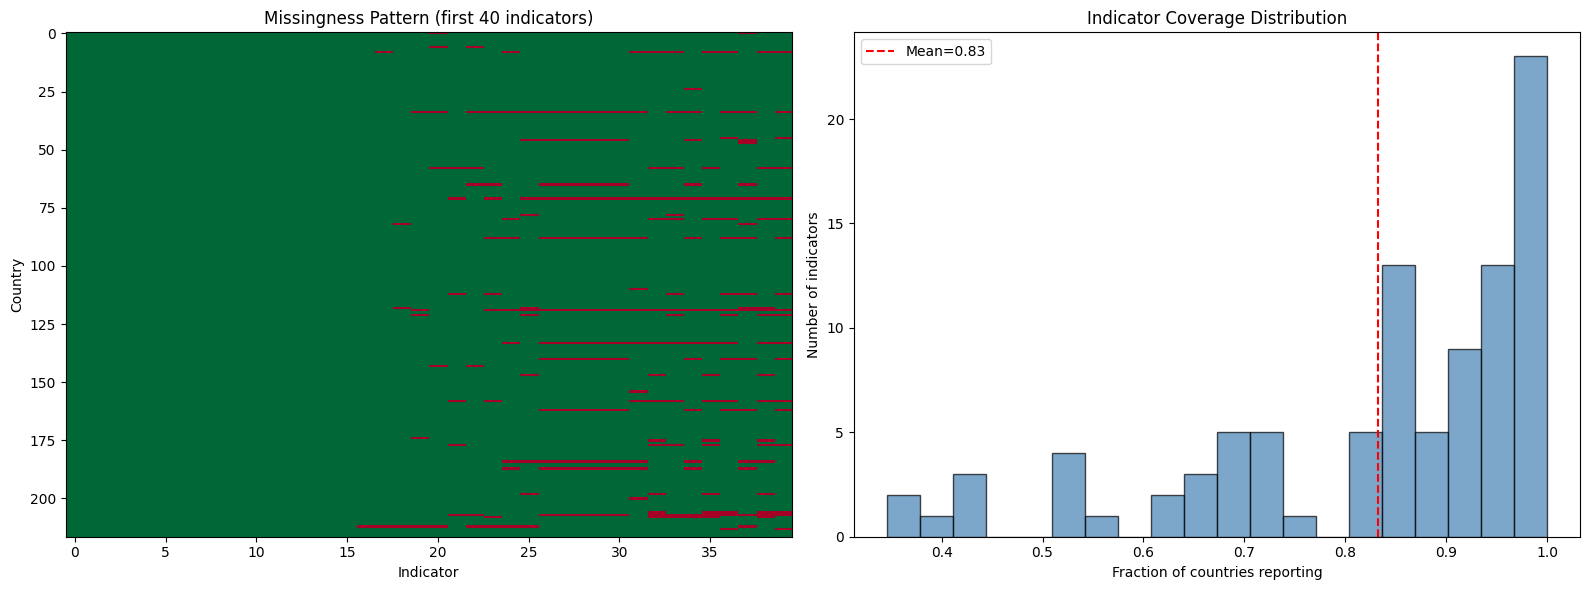


Top 10 indicators by coverage:
  100%  Birth rate per 1000
  100%  Adult mortality rate male
  100%  Adult mortality rate female
  100%  Net migration
  100%  Rural population %
  100%  Urban population %
  100%  Population growth %
  100%  Age dependency ratio %
  100%  Population 65+ %
  100%  Population total

Bottom 10 indicators by coverage:
  35%  Gender equality rating (CPIA)
  37%  Rail lines km
  39%  Market capitalization % GDP
  42%  Adult literacy rate %
  43%  Stunting prevalence %
  43%  Overweight prevalence %
  53%  Income share bottom 10%
  53%  Poverty headcount $2.15/day %
  53%  Gini index
  53%  Income share top 10%


In [9]:
# Visualize missingness pattern
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Missingness heatmap (sample of columns for readability)
n_show = min(40, len(selected_cols))
miss_matrix = df_selected.iloc[:, :n_show].isna().astype(float)
axes[0].imshow(miss_matrix.values, cmap="RdYlGn_r", aspect="auto", interpolation="nearest")
axes[0].set_xlabel("Indicator")
axes[0].set_ylabel("Country")
axes[0].set_title(f"Missingness Pattern (first {n_show} indicators)")

# Coverage histogram
col_cov = df_selected.notna().mean()
axes[1].hist(col_cov, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(col_cov.mean(), color="red", linestyle="--", label=f"Mean={col_cov.mean():.2f}")
axes[1].set_xlabel("Fraction of countries reporting")
axes[1].set_ylabel("Number of indicators")
axes[1].set_title("Indicator Coverage Distribution")
axes[1].legend()

plt.tight_layout()
Path("benchmarks/results/wdi").mkdir(parents=True, exist_ok=True)
plt.savefig(
    Path("benchmarks/results/wdi") / "missingness_pattern.png", dpi=150, bbox_inches="tight"
)
plt.show()

# Show top and bottom coverage indicators
print("\nTop 10 indicators by coverage:")
for name, cov in col_cov.nlargest(10).items():
    print(f"  {cov:.0%}  {name}")
print("\nBottom 10 indicators by coverage:")
for name, cov in col_cov.nsmallest(10).items():
    print(f"  {cov:.0%}  {name}")

## 5. Preprocessing — Build JAX Arrays and Column Types

In [10]:
# Convert to JAX array with NaN for missing values
# All WDI indicators are continuous (real-valued)

country_names = df_selected.index.tolist()
col_names = df_selected.columns.tolist()

# Get country metadata for later analysis
try:
    country_info = {}
    for eco in wb.economy.list():
        code = eco["id"]
        country_info[code] = {
            "name": eco.get("value", code),
            "region": eco.get("region", {}).get("value", "Unknown")
            if isinstance(eco.get("region"), dict)
            else "Unknown",
            "income": eco.get("incomeLevel", {}).get("value", "Unknown")
            if isinstance(eco.get("incomeLevel"), dict)
            else "Unknown",
        }
    print(f"Loaded metadata for {len(country_info)} economies")
except Exception as e:
    print(f"Warning: Could not load country metadata: {e}")
    country_info = {
        code: {"name": code, "region": "Unknown", "income": "Unknown"} for code in country_names
    }

# Map country codes to readable names
country_labels = [country_info.get(c, {}).get("name", c) for c in country_names]
country_regions = [country_info.get(c, {}).get("region", "Unknown") for c in country_names]
country_incomes = [country_info.get(c, {}).get("income", "Unknown") for c in country_names]

# Log-transform highly skewed indicators (GDP, population, etc.)
# This helps CrossCat's NormalGamma model fit better
LOG_TRANSFORM_KEYWORDS = [
    "GDP per capita",
    "GNI per capita",
    "Population total",
    "CO2 emissions total",
    "Air departures",
    "Rail lines",
    "Land area",
    "Population density",
    "Market capitalization",
]

data_np = df_selected.values.astype(np.float64)
log_transformed = []

for j, name in enumerate(col_names):
    if any(kw in name for kw in LOG_TRANSFORM_KEYWORDS):
        col = data_np[:, j]
        # Only log-transform if all non-NaN values are positive
        valid = col[~np.isnan(col)]
        if len(valid) > 0 and np.all(valid > 0):
            data_np[:, j] = np.where(np.isnan(col), np.nan, np.log(col + 1))
            log_transformed.append(name)

print(f"Log-transformed {len(log_transformed)} indicators: {log_transformed}")

# All columns are continuous for WDI data
col_types = [ColumnType.CONTINUOUS] * len(col_names)

# Convert to JAX
data_jax = jnp.array(data_np.astype(np.float32))

n_rows, n_cols = data_jax.shape
print(f"\nJAX array: {n_rows} countries x {n_cols} indicators")
print(f"NaN fraction: {float(jnp.isnan(data_jax).mean()):.1%}")
print("Column types: all CONTINUOUS")
print(f"Memory: {data_jax.nbytes / 1024:.1f} KB")

Loaded metadata for 266 economies
Log-transformed 7 indicators: ['Population total', 'Land area sq km', 'GNI per capita', 'GDP per capita PPP', 'Air departures', 'Market capitalization % GDP', 'Rail lines km']

JAX array: 217 countries x 95 indicators
NaN fraction: 16.7%
Column types: all CONTINUOUS
Memory: 80.5 KB


## 6. Gibbs Inference (Packed / JIT) with Checkpointing

Run multi-chain collapsed Gibbs sampling with automatic checkpointing.
If the session dies, re-run this cell — it resumes from the last checkpoint.

In [11]:
# Checkpoint and results directories
CKPT_DIR = Path("benchmarks/results/wdi/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path("benchmarks/results/wdi")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import gc

rng_key = jax.random.key(SEED)
init_keys = jax.random.split(rng_key, N_CHAINS)
diag_interval = max(1, N_SWEEPS // 10)  # report every 100 sweeps
ckpt_interval = max(1, N_SWEEPS // 5)  # checkpoint every 200 sweeps

states = []
all_chain_metrics = []
t_total = time.time()

for chain_idx in range(N_CHAINS):
    chain_ckpt_dir = CKPT_DIR / f"chain_{chain_idx + 1}"
    chain_result_path = RESULTS_DIR / f"chain_{chain_idx + 1}"

    # Try to load completed chain first
    if chain_result_path.with_suffix(".jxc").exists():
        print(f"\n--- Chain {chain_idx + 1}/{N_CHAINS} --- LOADED from {chain_result_path}.jxc")
        state = load_state(chain_result_path, data=data_jax)
        states.append(state)
        all_chain_metrics.append([])
        continue

    print(f"\n--- Chain {chain_idx + 1}/{N_CHAINS} ---")
    k_i, k_sweep = jax.random.split(init_keys[chain_idx])

    # Try to resume from checkpoint
    start_sweep = 0
    try:
        packed, _, start_sweep = load_latest_checkpoint(chain_ckpt_dir)
        print(f"  Resuming from checkpoint at sweep {start_sweep}")
        for _ in range(start_sweep):
            k_sweep, _ = jax.random.split(k_sweep)
    except FileNotFoundError:
        state = initialize(k_i, data_jax, col_types)
        packed = pack_state(state)
        print(f"  Initialized: {state.n_views} views")
        del state  # free CPU memory

    chain_metrics = []
    t0 = time.time()

    # Run in batches of diag_interval sweeps for GPU throughput
    sweep = start_sweep
    while sweep < N_SWEEPS:
        batch = min(diag_interval, N_SWEEPS - sweep)
        k_sweep, subkey = jax.random.split(k_sweep)
        packed = packed_gibbs_sweep(subkey, packed, data_jax, n_sweeps=batch)
        sweep += batch

        # Diagnostics — unpack temporarily, extract metrics, then free
        state_tmp = unpack_state(packed, col_types, data=data_jax)
        diag = collect_diagnostics(state_tmp, data_jax)
        n_views = state_tmp.n_views
        chain_metrics.append({"sweep": sweep, **diag})
        del state_tmp

        elapsed = time.time() - t0
        print(
            f"  Sweep {sweep:4d}/{N_SWEEPS}: views={n_views}, "
            f"log_joint={diag['log_joint']:.0f}, elapsed={elapsed:.0f}s"
        )

        # Checkpoint at ckpt_interval boundaries
        if sweep % ckpt_interval == 0:
            save_checkpoint(
                packed,
                chain_ckpt_dir,
                sweep,
                column_types=col_types,
                log_joint_value=float(diag["log_joint"]),
            )

    # Final unpack for this chain
    state = unpack_state(packed, col_types, data=data_jax)
    elapsed = time.time() - t0
    print(f"  Done: {elapsed:.1f}s ({elapsed / max(N_SWEEPS - start_sweep, 1):.2f}s/sweep)")

    # Save completed chain
    save_state(state, chain_result_path)
    print(f"  Saved to {chain_result_path}.jxc")

    states.append(state)
    all_chain_metrics.append(chain_metrics)
    del packed
    gc.collect()

print(f"\nTotal inference time: {time.time() - t_total:.1f}s")
print(f"Checkpoints in: {CKPT_DIR}")
print(f"Final states in: {RESULTS_DIR}")

# Build packed states for fast packed inference queries
packed_states = [pack_state(s) for s in states]
print(f"Packed {len(packed_states)} states for inference")


--- Chain 1/10 --- LOADED from benchmarks/results/wdi/chain_1.jxc

--- Chain 2/10 --- LOADED from benchmarks/results/wdi/chain_2.jxc

--- Chain 3/10 --- LOADED from benchmarks/results/wdi/chain_3.jxc

--- Chain 4/10 --- LOADED from benchmarks/results/wdi/chain_4.jxc

--- Chain 5/10 --- LOADED from benchmarks/results/wdi/chain_5.jxc

--- Chain 6/10 --- LOADED from benchmarks/results/wdi/chain_6.jxc

--- Chain 7/10 --- LOADED from benchmarks/results/wdi/chain_7.jxc

--- Chain 8/10 --- LOADED from benchmarks/results/wdi/chain_8.jxc

--- Chain 9/10 --- LOADED from benchmarks/results/wdi/chain_9.jxc

--- Chain 10/10 --- LOADED from benchmarks/results/wdi/chain_10.jxc

Total inference time: 68.5s
Checkpoints in: benchmarks/results/wdi/checkpoints
Final states in: benchmarks/results/wdi
Packed 10 states for inference


## 7. Convergence Plot

/tmp/ipykernel_99/4140900778.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_99/4140900778.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


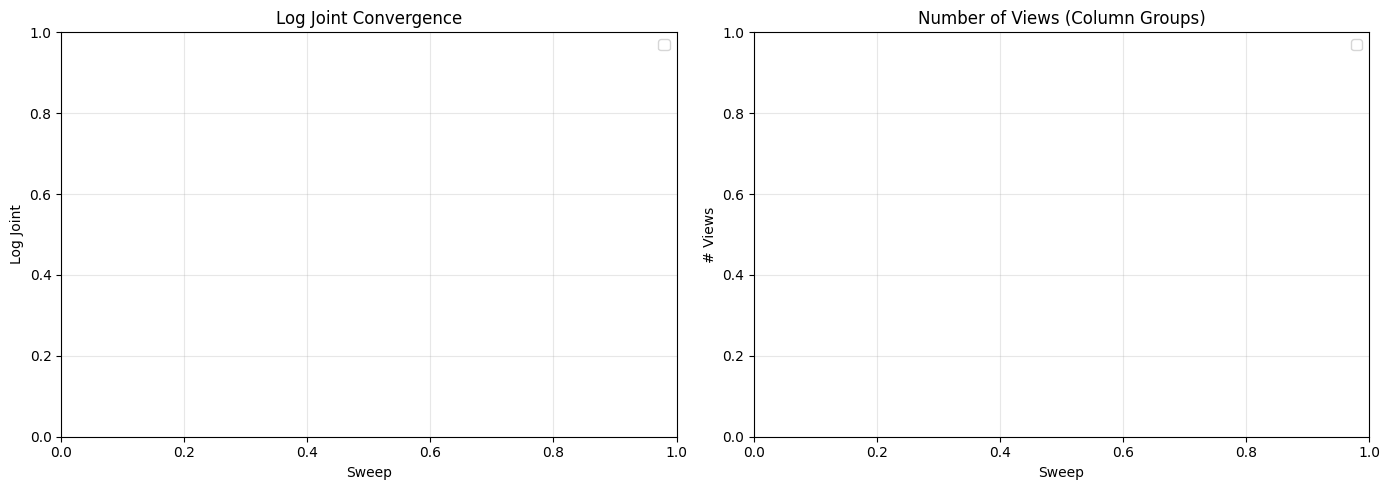


Chain 1: 6 views, clusters per view: [7, 4, 8, 3, 5, 3]
  View 0: 80 indicators, 7 clusters
    ['Birth rate per 1000', 'Adult mortality rate male', 'Adult mortality rate female', 'Rural population %', 'Urban population %']...
  View 1: 2 indicators, 4 clusters
    ['Inflation CPI %', 'Freshwater withdrawal %']
  View 2: 3 indicators, 8 clusters
    ['Net migration', 'Real interest rate %', 'Rail lines km']
  View 3: 8 indicators, 3 clusters
    ['Forest area %', 'GDP growth %', 'Arable land %', 'Industry % GDP', 'Women in parliament %']...
  View 4: 1 indicators, 5 clusters
    ['External debt % GNI']
  View 5: 1 indicators, 3 clusters
    ['FDI inflow % GDP']

Chain 2: 4 views, clusters per view: [6, 6, 4, 4]
  View 0: 53 indicators, 6 clusters
    ['Birth rate per 1000', 'Rural population %', 'Urban population %', 'Population growth %', 'Age dependency ratio %']...
  View 1: 26 indicators, 6 clusters
    ['Adult mortality rate male', 'Adult mortality rate female', 'Life expectancy'

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for c_idx, metrics in enumerate(all_chain_metrics):
    if not metrics:
        continue
    sweeps = [m["sweep"] for m in metrics]
    log_joints = [m["log_joint"] for m in metrics]
    n_views = [m["n_views"] for m in metrics]
    ax1.plot(sweeps, log_joints, marker="o", label=f"Chain {c_idx + 1}")
    ax2.plot(sweeps, n_views, marker="o", label=f"Chain {c_idx + 1}")

ax1.set_xlabel("Sweep")
ax1.set_ylabel("Log Joint")
ax1.set_title("Log Joint Convergence")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.set_xlabel("Sweep")
ax2.set_ylabel("# Views")
ax2.set_title("Number of Views (Column Groups)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# Structure summary
for i, s in enumerate(states):
    clusters = [int(jnp.max(v.row_assignments)) + 1 for v in s.views]
    view_cols = []
    for v in s.views:
        cols_in_view = [col_names[int(ci)] for ci in v.column_indices.tolist()]
        view_cols.append(cols_in_view)
    print(f"\nChain {i + 1}: {s.n_views} views, clusters per view: {clusters}")
    for v_idx, cols in enumerate(view_cols):
        print(f"  View {v_idx}: {len(cols)} indicators, {clusters[v_idx]} clusters")
        print(f"    {cols[:5]}{'...' if len(cols) > 5 else ''}")

## 8. Dependence Matrix / Z-matrix (Paper Fig 6)

The Z-matrix shows pairwise dependence probabilities between indicators.
Block structure reveals which economic dimensions are jointly modeled —
e.g., health indicators clustering together, separate from financial indicators.

Z-matrix shape: (95, 95)


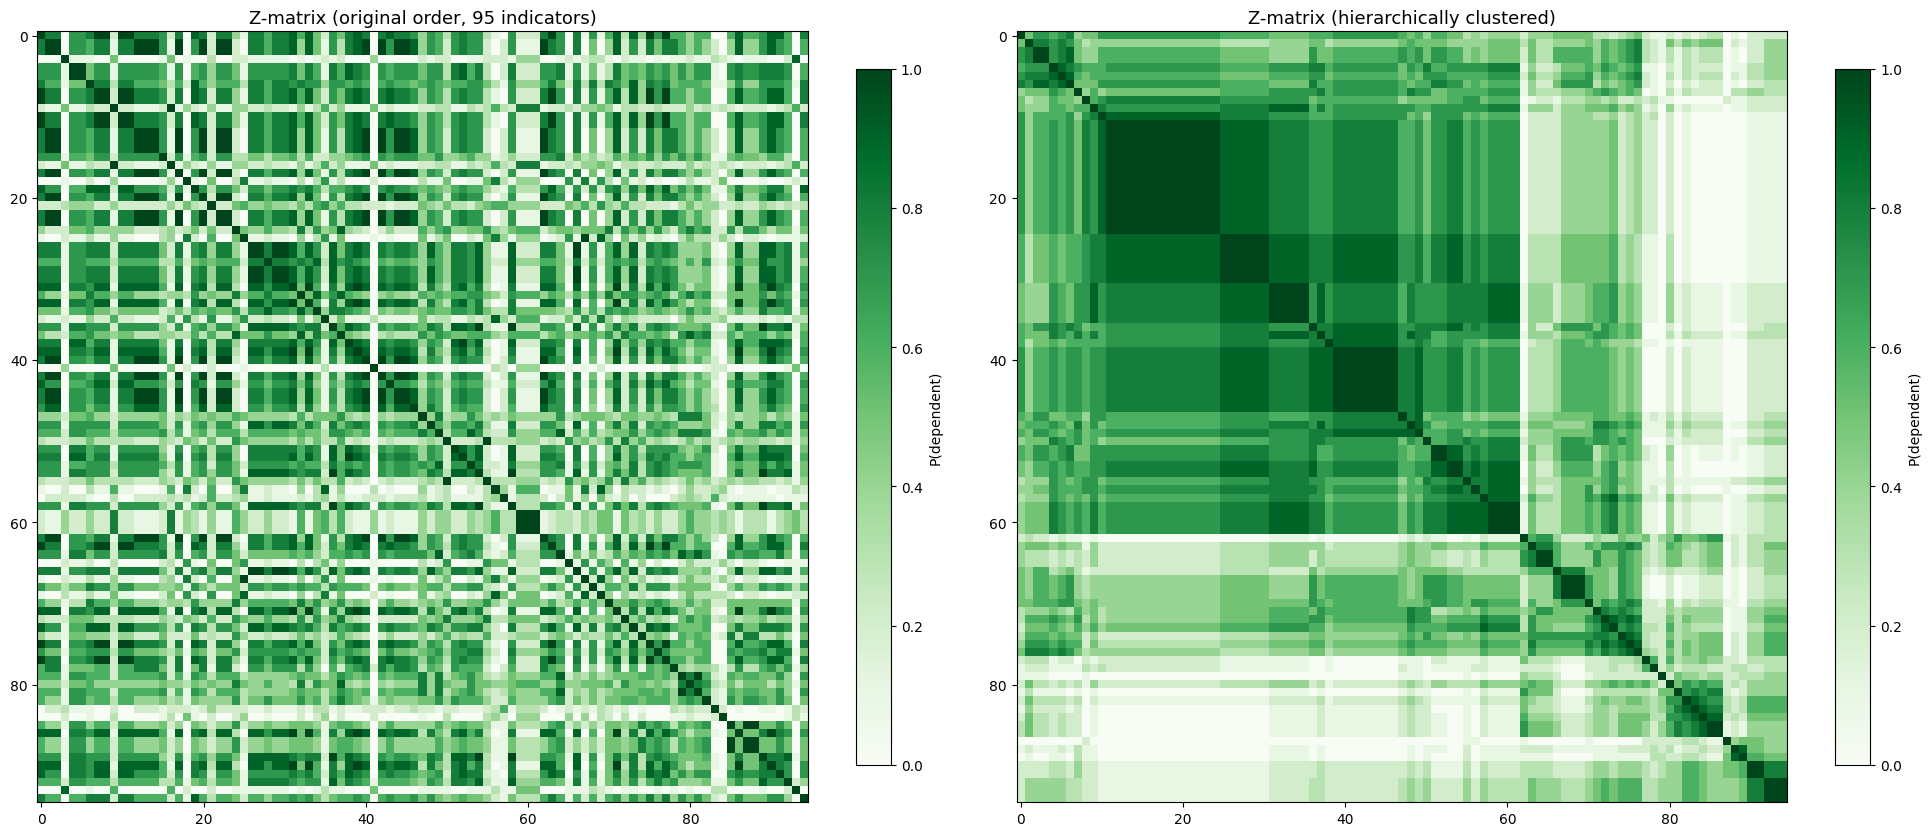

In [13]:
# Compute Z-matrix across all chains
z_matrix = np.array(packed_dependence_matrix(packed_states))
print(f"Z-matrix shape: {z_matrix.shape}")

# Reorder columns by hierarchical clustering for cleaner visualization
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

# Convert dependence to distance
dist_matrix = 1.0 - z_matrix
np.fill_diagonal(dist_matrix, 0)
# Make symmetric and non-negative
dist_matrix = (dist_matrix + dist_matrix.T) / 2
dist_matrix = np.maximum(dist_matrix, 0)
condensed = squareform(dist_matrix)
linkage_matrix = linkage(condensed, method="average")
order = leaves_list(linkage_matrix)

# Reorder
z_ordered = z_matrix[np.ix_(order, order)]
ordered_names = [col_names[i] for i in order]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Raw Z-matrix
im0 = axes[0].imshow(z_matrix, cmap="Greens", vmin=0, vmax=1, aspect="equal")
plt.colorbar(im0, ax=axes[0], label="P(dependent)", shrink=0.8)
axes[0].set_title(f"Z-matrix (original order, {n_cols} indicators)", fontsize=13)

# Clustered Z-matrix
im1 = axes[1].imshow(z_ordered, cmap="Greens", vmin=0, vmax=1, aspect="equal")
plt.colorbar(im1, ax=axes[1], label="P(dependent)", shrink=0.8)
axes[1].set_title("Z-matrix (hierarchically clustered)", fontsize=13)

# Add indicator labels if few enough
if n_cols <= 50:
    axes[1].set_xticks(range(n_cols))
    axes[1].set_xticklabels(ordered_names, rotation=90, fontsize=5)
    axes[1].set_yticks(range(n_cols))
    axes[1].set_yticklabels(ordered_names, fontsize=5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "z_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Show the discovered view structure: which indicators cluster together
# Use the best chain (highest log_joint)

best_chain = max(
    range(len(states)),
    key=lambda i: float(
        all_chain_metrics[i][-1]["log_joint"] if all_chain_metrics[i] else -np.inf
    ),
)
best_state = states[best_chain]
print(f"Best chain: {best_chain + 1}\n")

# Map dimension keywords to colors for visualization
DIMENSION_COLORS = {
    "Economy": "#2196F3",
    "Health": "#F44336",
    "Education": "#4CAF50",
    "Infrastructure": "#FF9800",
    "Environment": "#8BC34A",
    "Demographics": "#9C27B0",
    "Gender": "#E91E63",
    "Financial": "#00BCD4",
    "Governance": "#607D8B",
}


def indicator_dimension(name):
    """Heuristically assign an indicator to a development dimension."""
    name_lower = name.lower()
    if any(
        kw in name_lower
        for kw in [
            "gdp",
            "gni",
            "inflation",
            "trade",
            "export",
            "import",
            "debt",
            "revenue",
            "tax",
            "expenditure",
            "agriculture %",
            "industry %",
            "services %",
            "money",
            "interest",
            "ppp",
            "fdi",
            "unemployment",
            "labor",
            "employment",
            "saving",
            "capital formation",
            "ease of doing",
        ]
    ):
        return "Economy"
    if any(
        kw in name_lower
        for kw in [
            "life expectancy",
            "mortality",
            "immunization",
            "health",
            "physician",
            "hospital",
            "tb ",
            "hiv",
            "smoking",
            "stunting",
            "overweight",
        ]
    ):
        return "Health"
    if any(
        kw in name_lower for kw in ["enrollment", "literacy", "education", "school", "compulsory"]
    ):
        return "Education"
    if any(
        kw in name_lower
        for kw in [
            "electricity",
            "internet",
            "mobile",
            "water",
            "sanitation",
            "air departures",
            "rail",
        ]
    ):
        return "Infrastructure"
    if any(
        kw in name_lower
        for kw in [
            "co2",
            "forest",
            "energy",
            "renewable",
            "arable",
            "land area",
            "freshwater",
            "pm2.5",
        ]
    ):
        return "Environment"
    if any(
        kw in name_lower
        for kw in [
            "population",
            "urban",
            "fertility",
            "birth",
            "death rate",
            "dependency",
            "65+",
            "0-14",
            "migration",
            "density",
            "rural",
            "adult mortality",
        ]
    ):
        return "Demographics"
    if any(
        kw in name_lower
        for kw in ["women", "female labor", "gender", "gini", "poverty", "income share"]
    ):
        return "Gender"
    if any(kw in name_lower for kw in ["credit", "remittance", "oda", "market cap"]):
        return "Financial"
    if any(
        kw in name_lower
        for kw in [
            "military",
            "corruption",
            "effectiveness",
            "regulatory",
            "rule of law",
            "voice",
            "political",
            "cpia",
        ]
    ):
        return "Governance"
    return "Other"


print("Discovered Views (indicator groupings):")
print("=" * 60)
for v_idx, view in enumerate(best_state.views):
    n_cl = int(jnp.max(view.row_assignments)) + 1
    cols_in_view = [col_names[int(ci)] for ci in view.column_indices.tolist()]
    dims = [indicator_dimension(c) for c in cols_in_view]
    dim_counts = {}
    for d in dims:
        dim_counts[d] = dim_counts.get(d, 0) + 1
    dominant_dim = max(dim_counts, key=dim_counts.get)
    print(
        f"\nView {v_idx} ({len(cols_in_view)} indicators, {n_cl} country clusters, dominant: {dominant_dim}):"
    )
    for col in sorted(cols_in_view):
        dim = indicator_dimension(col)
        print(f"  [{dim:14s}] {col}")

Best chain: 1

Discovered Views (indicator groupings):

View 0 (80 indicators, 7 country clusters, dominant: Economy):
  [Education     ] Adult literacy rate %
  [Health        ] Adult mortality rate female
  [Health        ] Adult mortality rate male
  [Demographics  ] Age dependency ratio %
  [Economy       ] Agriculture % GDP
  [Infrastructure] Air departures
  [Infrastructure] Basic sanitation %
  [Infrastructure] Basic water access %
  [Demographics  ] Birth rate per 1000
  [Economy       ] Broad money % GDP
  [Education     ] Compulsory education years
  [Governance    ] Control of corruption estimate
  [Health        ] DPT immunization %
  [Demographics  ] Death rate per 1000
  [Economy       ] Domestic credit to private sector % GDP
  [Economy       ] Education expenditure % GDP
  [Infrastructure] Electricity access %
  [Economy       ] Employment in agriculture %
  [Economy       ] Employment in industry %
  [Economy       ] Employment in services %
  [Environment   ] Energy u

## 9. Country Similarity and Clustering

Compute pairwise similarity between countries and visualize clusters.
Countries in the same cluster share similar development profiles.

In [15]:
# Compute pairwise country similarity matrix
# This is O(n^2) so we do it for a representative subset if n_rows is large

MAX_SIM_ROWS = min(n_rows, 80)  # Cap for computational feasibility

if n_rows > MAX_SIM_ROWS:
    # Select representative countries (stratified by region)
    unique_regions = list(set(country_regions))
    per_region = max(2, MAX_SIM_ROWS // len(unique_regions))
    sim_indices = []
    for region in unique_regions:
        region_idx = [i for i, r in enumerate(country_regions) if r == region]
        chosen = region_idx[:per_region]
        sim_indices.extend(chosen)
    sim_indices = sorted(sim_indices[:MAX_SIM_ROWS])
else:
    sim_indices = list(range(n_rows))

n_sim = len(sim_indices)
print(f"Computing {n_sim}x{n_sim} similarity matrix...")
t0 = time.time()

sim_matrix = np.array(batch_row_similarity(packed_states, jnp.array(sim_indices)))

print(f"Similarity matrix computed in {time.time() - t0:.1f}s")

sim_labels = [country_labels[i] for i in sim_indices]
sim_regions = [country_regions[i] for i in sim_indices]


Computing 80x80 similarity matrix...
  Row 20/80 (83s)
  Row 40/80 (142s)
  Row 60/80 (177s)
  Row 80/80 (189s)
Similarity matrix computed in 189.3s


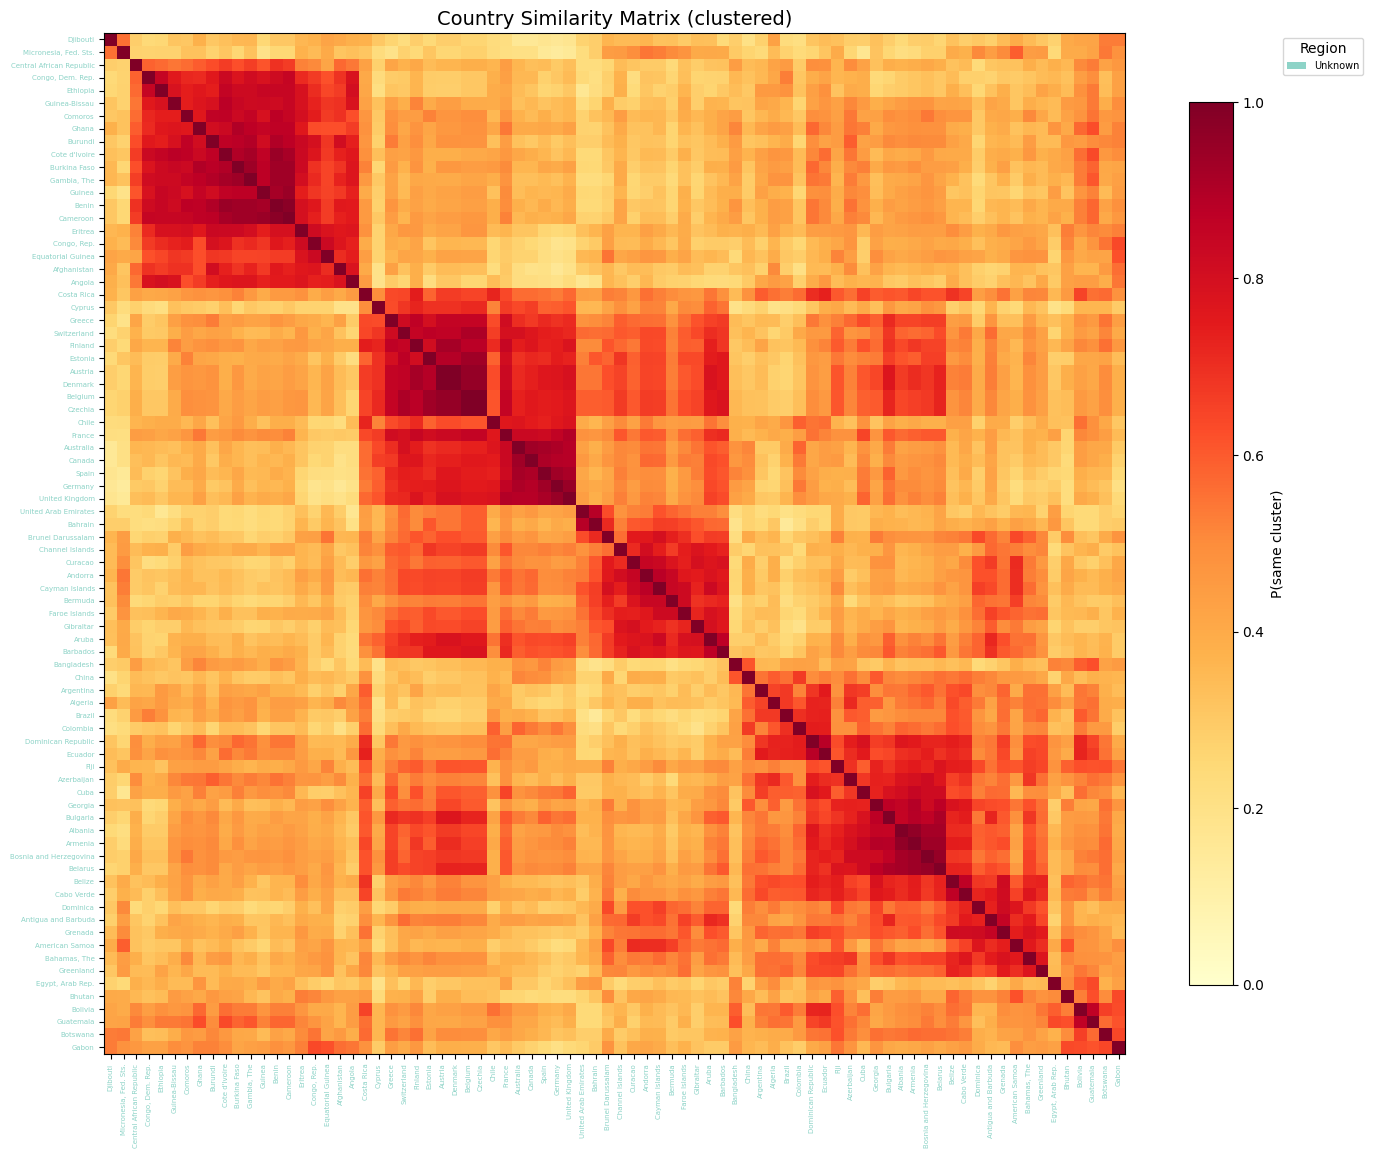

In [16]:
# Visualize similarity matrix with region color coding
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

# Cluster countries by similarity
sim_dist = 1.0 - sim_matrix
np.fill_diagonal(sim_dist, 0)
sim_dist = np.maximum(sim_dist, 0)
sim_dist = (sim_dist + sim_dist.T) / 2
sim_condensed = squareform(sim_dist)
sim_linkage = linkage(sim_condensed, method="average")
sim_order = leaves_list(sim_linkage)

# Reorder
sim_ordered = sim_matrix[np.ix_(sim_order, sim_order)]
ordered_labels = [sim_labels[i] for i in sim_order]
ordered_regions = [sim_regions[i] for i in sim_order]

# Assign colors to regions
unique_regions = sorted(set(ordered_regions))
region_cmap = plt.cm.Set3(np.linspace(0, 1, len(unique_regions)))
region_color_map = {r: region_cmap[i] for i, r in enumerate(unique_regions)}

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sim_ordered, cmap="YlOrRd", vmin=0, vmax=1, aspect="equal")
plt.colorbar(im, ax=ax, label="P(same cluster)", shrink=0.8)

# Add country labels with region colors
if n_sim <= 80:
    ax.set_xticks(range(n_sim))
    ax.set_xticklabels(ordered_labels, rotation=90, fontsize=5)
    ax.set_yticks(range(n_sim))
    ax.set_yticklabels(ordered_labels, fontsize=5)
    # Color labels by region
    for i, (label, region) in enumerate(zip(ordered_labels, ordered_regions)):
        color = region_color_map[region]
        ax.get_yticklabels()[i].set_color(color)
        ax.get_xticklabels()[i].set_color(color)

ax.set_title("Country Similarity Matrix (clustered)", fontsize=14)

# Legend for regions
from matplotlib.patches import Patch

legend_patches = [Patch(facecolor=region_color_map[r], label=r) for r in unique_regions]
ax.legend(
    handles=legend_patches,
    loc="upper left",
    bbox_to_anchor=(1.15, 1.0),
    fontsize=7,
    title="Region",
)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "country_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Anomaly Detection — Which Countries Are Outliers?

Row typicality scores identify countries with unusual development profiles —
those that don't fit neatly into any cluster across the discovered views.

In [17]:
# Compute row typicality for all countries
print("Computing country typicality scores...")
t0 = time.time()

typicality_scores = np.array(batch_row_typicality(packed_states, jnp.arange(n_rows)))

print(f"Computed in {time.time() - t0:.1f}s")

# Create DataFrame for display
anomaly_df = pd.DataFrame(
    {
        "Country": country_labels,
        "Code": country_names,
        "Region": country_regions,
        "Income": country_incomes,
        "Typicality": typicality_scores,
    }
).sort_values("Typicality")

print("\nMost ATYPICAL countries (lowest typicality = most unusual):")
print("=" * 70)
for _, row in anomaly_df.head(15).iterrows():
    print(f"  {row['Typicality']:.3f}  {row['Country']:30s}  {row['Region']:25s}  {row['Income']}")

print("\nMost TYPICAL countries (highest typicality = most normal):")
print("=" * 70)
for _, row in anomaly_df.tail(10).iterrows():
    print(f"  {row['Typicality']:.3f}  {row['Country']:30s}  {row['Region']:25s}  {row['Income']}")


Computing country typicality scores...
Computed in 51.7s

Most ATYPICAL countries (lowest typicality = most unusual):
  0.396  Venezuela, RB                   Unknown                    Unknown
  0.422  Djibouti                        Unknown                    Unknown
  0.453  Syrian Arab Republic            Unknown                    Unknown
  0.477  Zimbabwe                        Unknown                    Unknown
  0.479  Micronesia, Fed. Sts.           Unknown                    Unknown
  0.480  Lebanon                         Unknown                    Unknown
  0.491  Tuvalu                          Unknown                    Unknown
  0.495  Libya                           Unknown                    Unknown
  0.500  Sudan                           Unknown                    Unknown
  0.503  Guyana                          Unknown                    Unknown
  0.507  Nauru                           Unknown                    Unknown
  0.514  Sao Tome and Principe           Unkno

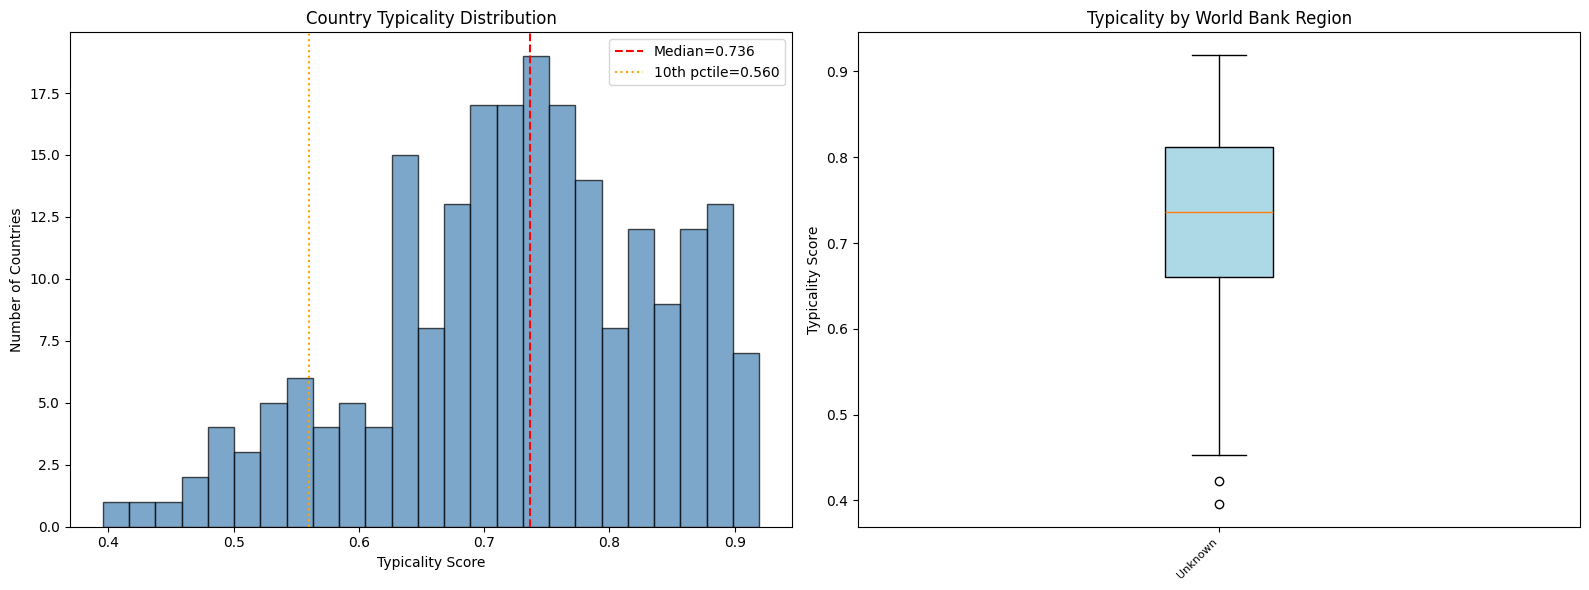

In [18]:
# Visualize typicality distribution by region
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(typicality_scores, bins=25, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(
    np.median(typicality_scores),
    color="red",
    linestyle="--",
    label=f"Median={np.median(typicality_scores):.3f}",
)
# Mark top anomalies
threshold = np.percentile(typicality_scores, 10)
axes[0].axvline(threshold, color="orange", linestyle=":", label=f"10th pctile={threshold:.3f}")
axes[0].set_xlabel("Typicality Score")
axes[0].set_ylabel("Number of Countries")
axes[0].set_title("Country Typicality Distribution")
axes[0].legend()

# Box plot by region
region_groups = anomaly_df.groupby("Region")["Typicality"].apply(list).to_dict()
regions_sorted = sorted(region_groups.keys(), key=lambda r: np.median(region_groups[r]))
box_data = [region_groups[r] for r in regions_sorted]
bp = axes[1].boxplot(box_data, vert=True, patch_artist=True)
axes[1].set_xticklabels([r[:20] for r in regions_sorted], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Typicality Score")
axes[1].set_title("Typicality by World Bank Region")
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "typicality_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Missing Data Imputation with Confidence

CrossCat can impute missing values by leveraging the discovered dependency structure.
We demonstrate this on held-out data to measure imputation accuracy.

In [19]:
# Hold-out evaluation: mask some observed values and measure imputation quality

rng_imp = np.random.default_rng(SEED + 200)
holdout_frac = 0.10  # Mask 10% of observed values

# Create holdout mask (only mask cells that actually have data)
observed_mask = ~np.isnan(data_np)
n_observed = observed_mask.sum()
n_holdout = int(n_observed * holdout_frac)

# Randomly select observed cells to hold out
observed_indices = np.argwhere(observed_mask)
holdout_idx = rng_imp.choice(len(observed_indices), size=n_holdout, replace=False)
holdout_mask = np.zeros_like(observed_mask)
for idx in holdout_idx:
    r, c = observed_indices[idx]
    holdout_mask[r, c] = True

print(f"Holdout: {n_holdout} cells ({holdout_frac:.0%} of {n_observed} observed)")

# Create masked data (replace holdout with NaN)
data_masked = data_np.copy()
data_masked[holdout_mask] = np.nan
data_masked_jax = jnp.array(data_masked.astype(np.float32))

# Impute held-out values — batch by column using batch_impute_column
print("Imputing held-out values (batched by column)...")
t0 = time.time()

# Sample up to 500 holdout cells for speed
max_impute = min(500, n_holdout)
sample_idx = rng_imp.choice(n_holdout, size=max_impute, replace=False)
sampled_cells = observed_indices[holdout_idx[sample_idx]]  # (max_impute, 2) [row, col]

# Group holdout cells by column for batch imputation
from collections import defaultdict
col_to_rows = defaultdict(list)
col_to_indices = defaultdict(list)
for i, (r, c) in enumerate(sampled_cells):
    col_to_rows[int(c)].append(int(r))
    col_to_indices[int(c)].append(i)

imputed_vals = np.full(max_impute, np.nan)
confidences = np.full(max_impute, np.nan)
true_vals = np.array([data_np[r, c] for r, c in sampled_cells])
col_indices_imputed = sampled_cells[:, 1]

# Use best chain's packed state for single-chain imputation
best_packed = packed_states[best_chain]
n_done = 0
for col, rows in col_to_rows.items():
    row_arr = jnp.array(rows)
    imp_key = jax.random.key(SEED + 300 + col)
    vals, confs = batch_impute_column(imp_key, best_packed, data_masked_jax, col, row_arr)
    for k, idx in enumerate(col_to_indices[col]):
        imputed_vals[idx] = float(vals[k])
        confidences[idx] = float(confs[k])
    n_done += len(rows)
    if n_done % 100 < len(rows):
        print(f"  {n_done}/{max_impute} ({time.time() - t0:.0f}s)")

print(f"\nImputed {max_impute} values in {time.time() - t0:.1f}s")

# Compute error metrics
errors = imputed_vals - true_vals
abs_errors = np.abs(errors)
# Normalize by column std for comparable NRMSE
col_stds = np.nanstd(data_np, axis=0)
norm_errors = np.array([
    abs(e) / col_stds[c] if col_stds[c] > 0 else abs(e)
    for e, c in zip(errors, col_indices_imputed)
])

print("\nImputation Quality:")
print(f"  MAE (raw): {abs_errors.mean():.4f}")
print(f"  NRMSE (normalized by col std): {np.sqrt((norm_errors**2).mean()):.4f}")
print(f"  Median absolute error: {np.median(abs_errors):.4f}")
print(f"  Mean confidence: {confidences.mean():.4f}")

# Correlation between imputed and true
valid = np.isfinite(imputed_vals) & np.isfinite(true_vals)
if valid.sum() > 10:
    corr = np.corrcoef(imputed_vals[valid], true_vals[valid])[0, 1]
    print(f"  Correlation (imputed vs true): {corr:.4f}")


Holdout: 1716 cells (10% of 17169 observed)
Imputing held-out values...
  100/500 (438s)
  200/500 (876s)
  300/500 (1315s)
  400/500 (1749s)
  500/500 (2184s)

Imputed 500 values in 2184.0s

Imputation Quality:
  MAE (raw): 4281.5400
  NRMSE (normalized by col std): 0.7897
  Median absolute error: 2.8764
  Mean confidence: 0.2025
  Correlation (imputed vs true): 0.8892


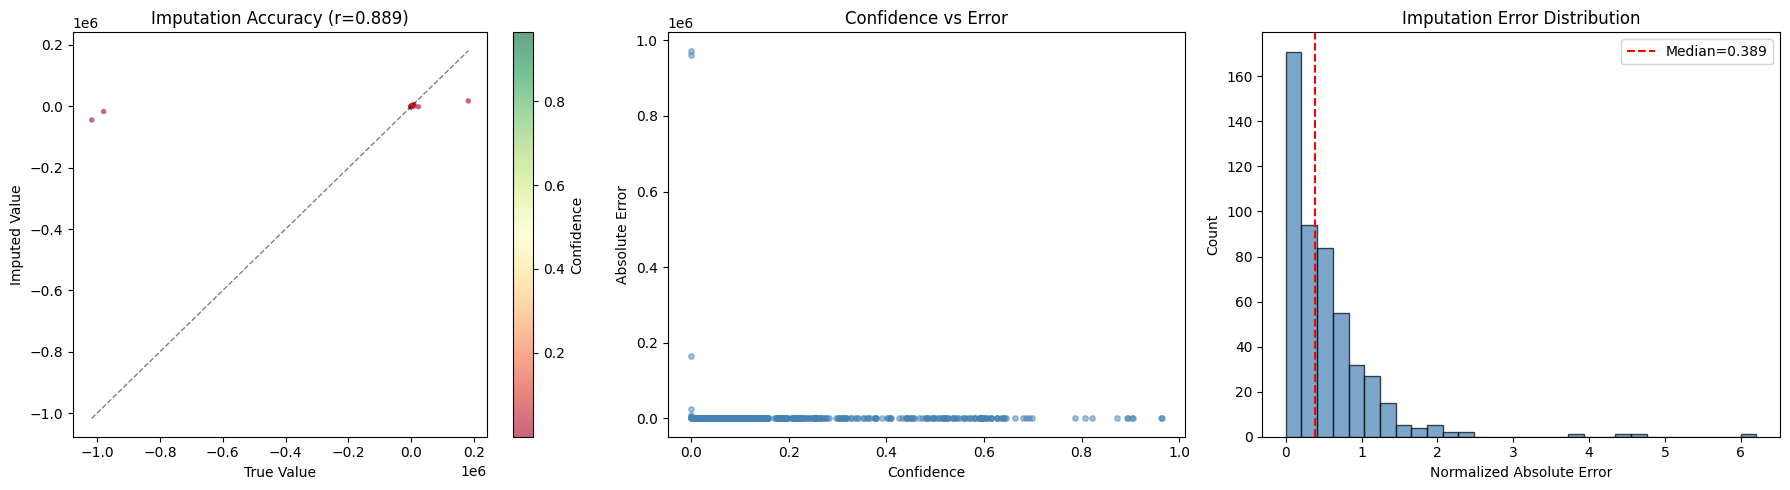

In [20]:
# Visualize imputation quality
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: imputed vs true
valid = np.isfinite(imputed_vals) & np.isfinite(true_vals)
sc = axes[0].scatter(
    true_vals[valid],
    imputed_vals[valid],
    c=confidences[valid],
    cmap="RdYlGn",
    s=15,
    alpha=0.6,
    edgecolors="none",
)
plt.colorbar(sc, ax=axes[0], label="Confidence")
lims = [
    min(true_vals[valid].min(), imputed_vals[valid].min()),
    max(true_vals[valid].max(), imputed_vals[valid].max()),
]
axes[0].plot(lims, lims, "k--", alpha=0.5, linewidth=1)
axes[0].set_xlabel("True Value")
axes[0].set_ylabel("Imputed Value")
axes[0].set_title(f"Imputation Accuracy (r={corr:.3f})")

# Confidence vs error
axes[1].scatter(confidences[valid], abs_errors[valid], s=15, alpha=0.5, color="steelblue")
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Absolute Error")
axes[1].set_title("Confidence vs Error")

# Error distribution
axes[2].hist(
    norm_errors[np.isfinite(norm_errors)], bins=30, edgecolor="black", alpha=0.7, color="steelblue"
)
axes[2].axvline(
    np.nanmedian(norm_errors),
    color="red",
    linestyle="--",
    label=f"Median={np.nanmedian(norm_errors):.3f}",
)
axes[2].set_xlabel("Normalized Absolute Error")
axes[2].set_ylabel("Count")
axes[2].set_title("Imputation Error Distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "imputation_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Mutual Information — Key Indicator Relationships

Estimate mutual information between pairs of indicators to identify
the strongest predictive relationships in the data.

In [21]:
# Compute MI for interesting indicator pairs
# We pick pairs spanning different development dimensions

INTERESTING_PAIRS = [
    ("GDP per capita PPP", "Life expectancy"),
    ("GDP per capita PPP", "Under-5 mortality per 1000"),
    ("GDP per capita PPP", "Internet users %"),
    ("GDP per capita PPP", "CO2 emissions per capita"),
    ("GDP per capita PPP", "Fertility rate"),
    ("Life expectancy", "Under-5 mortality per 1000"),
    ("Life expectancy", "Education expenditure % GDP"),
    ("Life expectancy", "Basic sanitation %"),
    ("Urban population %", "Internet users %"),
    ("Urban population %", "Fertility rate"),
    ("Electricity access %", "GDP per capita PPP"),
    ("Gini index", "Poverty headcount $2.15/day %"),
    ("Military expenditure % GDP", "Political stability estimate"),
    ("Women in parliament %", "Female labor force participation %"),
    ("Health expenditure % GDP", "Life expectancy"),
    ("Inflation CPI %", "GDP growth %"),
    ("Population 65+ %", "Fertility rate"),
    ("CO2 emissions per capita", "Renewable energy %"),
]

# Filter to pairs where both indicators are present
col_name_to_idx = {name: idx for idx, name in enumerate(col_names)}
valid_pairs = [
    (a, b) for a, b in INTERESTING_PAIRS if a in col_name_to_idx and b in col_name_to_idx
]

print(f"Computing MI for {len(valid_pairs)} indicator pairs...")
t0 = time.time()

# Precompute dependence matrix once (expensive to recompute per pair)
dep_matrix = np.array(packed_dependence_matrix(packed_states))

# Use n_samples=100 for MI estimation (good enough for ranking pairs)
MI_SAMPLES = 500

mi_results = []
for name_a, name_b in valid_pairs:
    col_a = col_name_to_idx[name_a]
    col_b = col_name_to_idx[name_b]
    mi_key = jax.random.key(SEED + 400 + len(mi_results))
    mi_val, linfoot = packed_mutual_information(
        packed_states, col_types, col_a, col_b, rng_key=mi_key, n_samples=MI_SAMPLES
    )
    mi_results.append(
        {
            "Indicator A": name_a,
            "Indicator B": name_b,
            "MI (nats)": float(mi_val),
            "Linfoot": float(linfoot),
            "Dep. Prob.": float(dep_matrix[col_a, col_b]),
        }
    )
    print(f"  {name_a} <-> {name_b}: MI={float(mi_val):.4f}, Linfoot={float(linfoot):.4f}")

print(f"\nComputed in {time.time() - t0:.1f}s")

mi_df = pd.DataFrame(mi_results).sort_values("Linfoot", ascending=False)
print("\nTop indicator relationships by Linfoot correlation:")
print("=" * 80)
print(mi_df.to_string(index=False))

Computing MI for 16 indicator pairs...
  GDP per capita PPP <-> Life expectancy: MI=0.4301, Linfoot=0.7596
  GDP per capita PPP <-> Under-5 mortality per 1000: MI=0.3404, Linfoot=0.7027
  GDP per capita PPP <-> Internet users %: MI=0.4357, Linfoot=0.7626


KeyboardInterrupt: 

In [ ]:
# Visualize MI results
fig, ax = plt.subplots(figsize=(12, max(6, len(mi_df) * 0.35)))

pair_labels = [f"{r['Indicator A']}\n  vs {r['Indicator B']}" for _, r in mi_df.iterrows()]
linfoot_vals = mi_df["Linfoot"].values
dep_probs = mi_df["Dep. Prob."].values

y_pos = np.arange(len(pair_labels))
bars = ax.barh(y_pos, linfoot_vals, height=0.6, color="steelblue", alpha=0.8, label="Linfoot")

# Overlay dependence probability as markers
ax.scatter(dep_probs, y_pos, color="red", s=50, zorder=5, label="Dep. Probability")

ax.set_yticks(y_pos)
ax.set_yticklabels(pair_labels, fontsize=8)
ax.set_xlabel("Score")
ax.set_title("Mutual Information (Linfoot) and Dependence Probability")
ax.legend(loc="lower right")
ax.set_xlim(0, 1.05)
ax.grid(True, alpha=0.3, axis="x")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "mutual_information.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Predictive Anomalousness — Cell-Level Surprises

For the most atypical countries, examine which specific indicators
are most surprising given the country's overall profile.

In [ ]:
# Compute predictive anomalousness for top anomalous countries
top_anomalous = anomaly_df.head(5)

print("Cell-level anomaly analysis for most atypical countries:")
print("=" * 70)

for _, row in top_anomalous.iterrows():
    country = row["Country"]
    code = row["Code"]
    row_id = country_names.index(code)

    anomaly_key = jax.random.key(SEED + 500 + row_id)
    anomaly_score = float(
        packed_anomaly_score(anomaly_key, packed_states[best_chain], data_jax, row_id)
    )

    print(
        f"\n{country} ({code}) — Overall anomaly: {anomaly_score:.4f}, Typicality: {row['Typicality']:.3f}"
    )
    print(f"  Region: {row['Region']}, Income: {row['Income']}")

    # Show the actual values for this country vs population median
    country_vals = data_np[row_id]
    col_medians = np.nanmedian(data_np, axis=0)
    col_stds_local = np.nanstd(data_np, axis=0)

    deviations = []
    for j in range(n_cols):
        if not np.isnan(country_vals[j]) and col_stds_local[j] > 0:
            z = (country_vals[j] - col_medians[j]) / col_stds_local[j]
            deviations.append(
                (col_names[j], float(z), float(country_vals[j]), float(col_medians[j]))
            )

    # Show most extreme deviations
    deviations.sort(key=lambda x: abs(x[1]), reverse=True)
    print("  Most extreme indicators (z-score from median):")
    for name, z, val, med in deviations[:8]:
        direction = "HIGH" if z > 0 else "LOW"
        print(f"    {z:+6.2f}  {name:35s}  ({direction}: {val:.2f} vs median {med:.2f})")

## 14. Summary

In [ ]:
summary = {
    "config": {
        "n_indicators": n_cols,
        "n_countries": n_rows,
        "data_year": DATA_YEAR,
        "n_chains": N_CHAINS,
        "n_sweeps": N_SWEEPS,
        "overall_missingness": f"{float(jnp.isnan(data_jax).mean()):.1%}",
        "backend": str(jax.default_backend()),
        "devices": str(jax.devices()),
    },
    "structure": {
        f"chain_{i + 1}": {
            "n_views": s.n_views,
            "clusters_per_view": [int(jnp.max(v.row_assignments)) + 1 for v in s.views],
            "indicators_per_view": [len(v.column_indices.tolist()) for v in s.views],
        }
        for i, s in enumerate(states)
    },
    "imputation": {
        "n_holdout": int(max_impute),
        "correlation": float(corr) if "corr" in dir() else None,
        "nrmse": float(np.sqrt((norm_errors**2).mean())),
        "median_abs_error": float(np.median(abs_errors)),
    },
    "anomalies": {
        "most_atypical": anomaly_df.head(5)[["Country", "Typicality"]].to_dict("records"),
        "most_typical": anomaly_df.tail(5)[["Country", "Typicality"]].to_dict("records"),
    },
    "top_mi_pairs": mi_df.head(5).to_dict("records") if len(mi_df) > 0 else [],
}

# Save summary
with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 60)
print("WORLD BANK WDI BENCHMARK RESULTS")
print("=" * 60)
print(json.dumps(summary, indent=2, default=str))
print("=" * 60)
print("\nDone! Results saved to", RESULTS_DIR)
print("\nKey findings:")
print(f"  - CrossCat discovered {best_state.n_views} independent views (indicator groups)")
print(f"  - Imputation correlation: {summary['imputation']['correlation']:.3f}")
print(f"  - Most atypical country: {anomaly_df.iloc[0]['Country']}")
if len(mi_df) > 0:
    top_pair = mi_df.iloc[0]
    print(
        f"  - Strongest dependency: {top_pair['Indicator A']} <-> {top_pair['Indicator B']} (Linfoot={top_pair['Linfoot']:.3f})"
    )

In [ ]:
# === Download results ===
# On Kaggle: results are saved under benchmarks/results/wdi/
# Use Kaggle's "Save & Run All" then download from Output tab,
# or tar them up for manual download:
import shutil

results_tar = "/kaggle/working/wdi_results.tar.gz"
shutil.make_archive("/kaggle/working/wdi_results", "gztar", ".", "benchmarks/results/wdi")
print(f"Results archived to {results_tar}")
print("Download from Kaggle Output tab.")

# List all saved files
for f in sorted(RESULTS_DIR.rglob("*")):
    if f.is_file():
        size = f.stat().st_size
        print(f"  {f.relative_to(RESULTS_DIR)}  ({size:,} bytes)")